# CoexpressDeconvolve
#### Automated Visium Standard Definition Spatial Transcriptomics data deconvolution

In [1]:
# %pip install h5py tqdm

In [2]:
import codeconv
import os

In [3]:
visium_path = "." 
output_folder = "."
config_path = "codeconv_config.json"

Step 1: Checking data format in ....
   > Found H5 file: ./filtered_feature_bc_matrix.h5. Loading...

LIBRARY DEPTH QC
Median UMI per Spot: 5120
Mean UMI per Spot:   5881
1th Percentile:      488


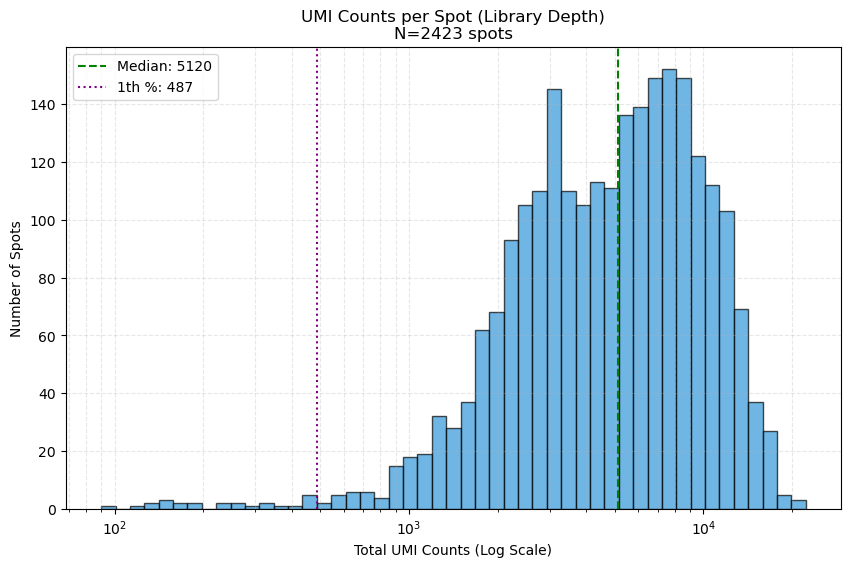

Step 1 took 0.269584 seconds


In [4]:
# STEP 1: LOAD
raw_counts, gene_names, barcodes, coords, total_umi, scales = codeconv.step1_acquisition_and_anchoring(visium_path)

Step 2: Loading Single Cell Standard from codeconv_config.json...
Step 2: Using 10 HK genes for calibration.


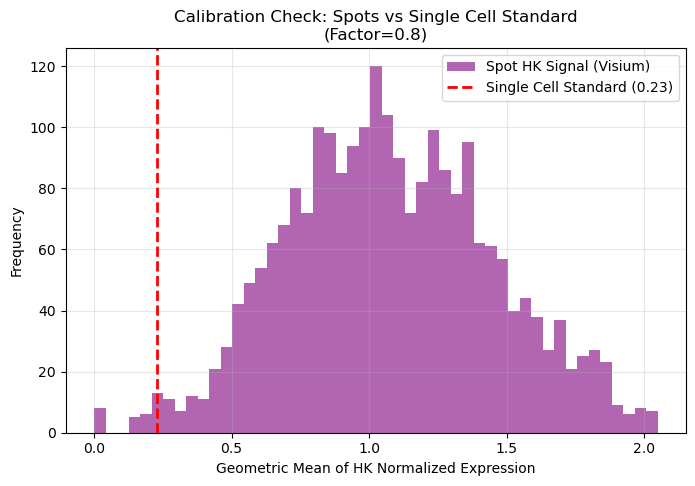

   > Single Cell Standard is: 0.23

FILTERING REPORT
Total Empty Spots (0 cells): 63 / 2423 (2.6%)
Among them are those with low UMI content: 55


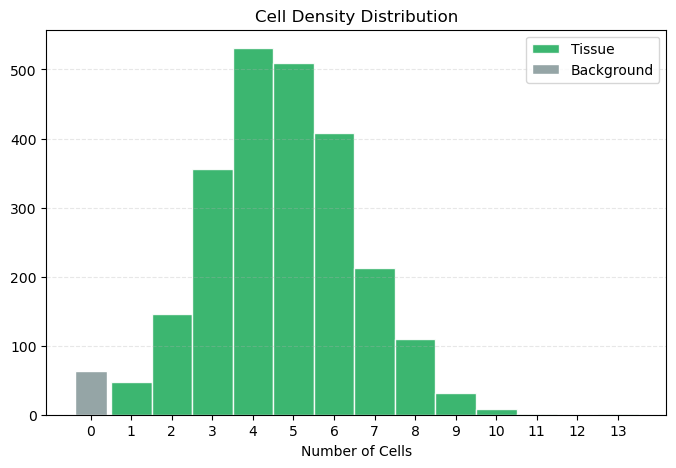

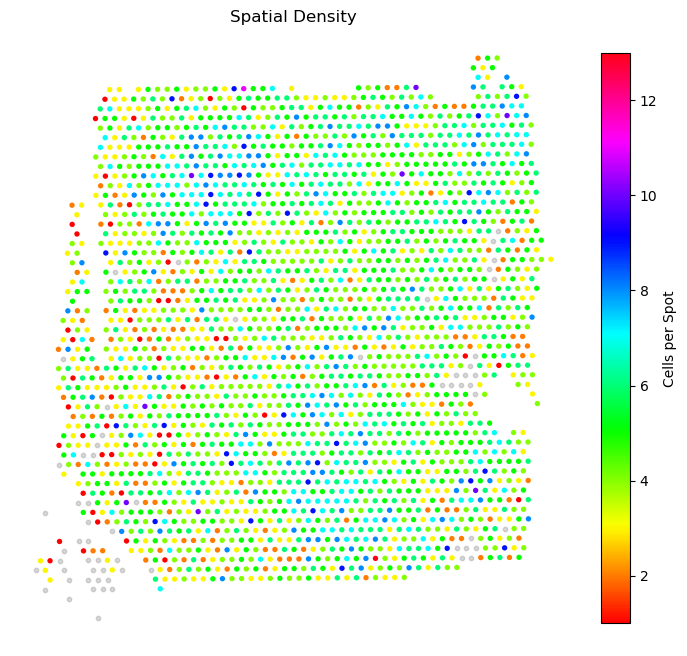


The number of cells on the Visium slide is 11272.
Step 2 took 0.205656 seconds


In [5]:
# STEP 2: DENSITY
n_cells_per_spot, engine_params = codeconv.step2_estimate_cell_density(
    raw_counts, 
    gene_names, 
    total_umi, 
    coords, 
    config_path,
    min_umi=900, 
    anchor_mean_factor=0.8, # adjust this factor to align the red line with the first non-zero peak on the graph
    colormap='hsv'
)

Step 3: Filtering transcriptome (Species: hs)...
   - Removed 47 noise genes.
   - Remaining feature space: 17896 genes.
Step 3: Selecting top 2000 HVGs for Model Training...


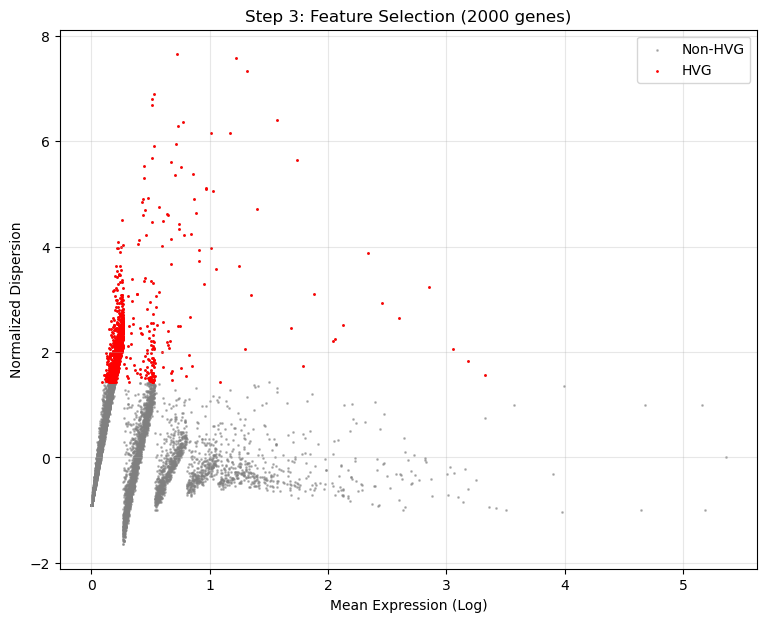

Step 3 Complete. Training set shape: (2423, 2000)
Step 3 took 0.221010 seconds


In [6]:
# STEP 3: Cleanup & Select HVGs
counts_clean, genes_clean, hvg_data, hvg_names = codeconv.step3_feature_selection(
    raw_counts, gene_names,
    species='hs', # 'hs' / 'mm'
    n_hvg=2000
)

Step 4: Constructing Gene Manifold for 17896 genes...
   - Preprocessing: Log-transformation and Scaling...
   - Decomposition: FastICA (30 components)...
   - Topology: UMAP Projection (Metric: Cosine)...


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


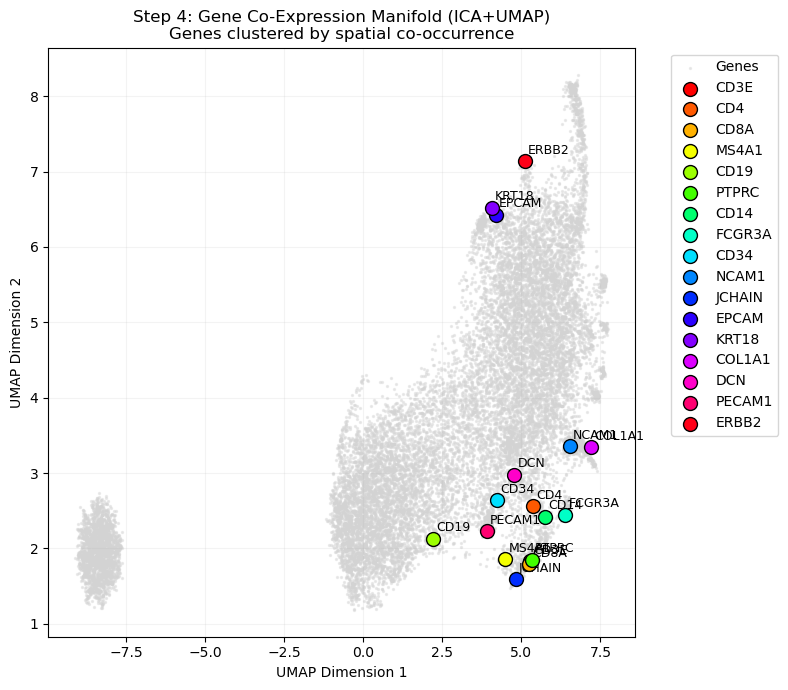

Step 4 took 34.706250 seconds


In [7]:
# STEP 4: Construct Gene Coexpression Manifold
embedding, reducer = codeconv.step4_gene_manifold(
    counts_clean, genes_clean, n_components = 30
)

Step 5: K-Sweep (Range: 3-20, Sampling: 100%)...


Training LDA models:   0%|          | 0/18 [00:00<?, ?it/s]

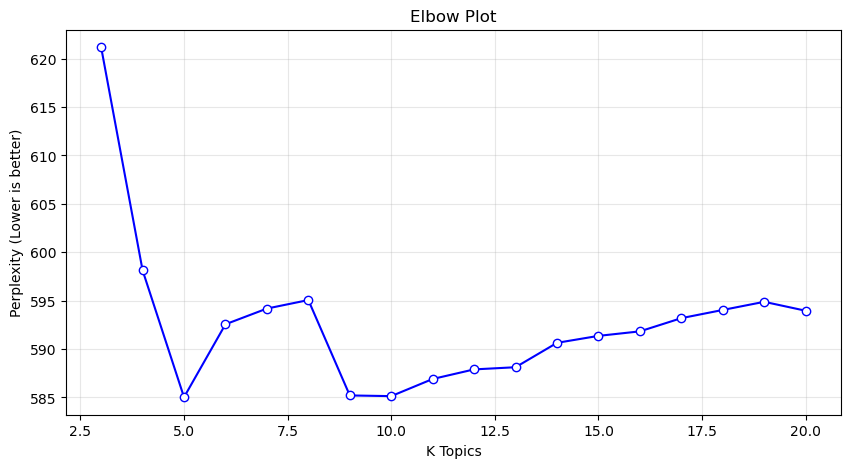

Step 5 took 70.677111 seconds


{3: np.float64(621.1729958520875),
 4: np.float64(598.1338353434908),
 5: np.float64(585.0220744103692),
 6: np.float64(592.5557271713997),
 7: np.float64(594.1798780663032),
 8: np.float64(595.0576870603111),
 9: np.float64(585.2067717061542),
 10: np.float64(585.1342549403583),
 11: np.float64(586.905699879686),
 12: np.float64(587.8959373543512),
 13: np.float64(588.1204267086945),
 14: np.float64(590.6403213990579),
 15: np.float64(591.3582477601767),
 16: np.float64(591.8246775714849),
 17: np.float64(593.188814754766),
 18: np.float64(594.035425458863),
 19: np.float64(594.8759463212323),
 20: np.float64(593.9547003805856)}

In [8]:
# STEP 5: K optimization

codeconv.step5_ksweep(hvg_data, min_k=3, max_k=20, step=1, subsample_frac=1,
                      doc_topic_prior=0.1,topic_word_prior=0.01)

In [12]:
# STEP 6: Final LDA Model & Manifold-Guided Projection

SELECTED_K = 10 

print(f"Starting Step 6 with K={SELECTED_K}...")

theta, beta_final, qc_df = codeconv.step6_final_deconvolution(
    hvg_data,      
    counts_clean,  
    genes_clean,
    hvg_names,
    n_topics=SELECTED_K,
    embedding=embedding,
    n_iters=30,
    k_neighbors=3,       # Nearest neighbors on the UMAP map
    min_sim=0.05,         # Minimum cosine expression similarity threshold
    doc_topic_prior=0.1,
    topic_word_prior=0.01
)

print("Top markers per topic:")
display(qc_df)

Starting Step 6 with K=10...
Step 6: Training Final LDA Model with chosen K=10...
iteration: 1 of max_iter: 30
iteration: 2 of max_iter: 30
iteration: 3 of max_iter: 30
iteration: 4 of max_iter: 30
iteration: 5 of max_iter: 30
iteration: 6 of max_iter: 30
iteration: 7 of max_iter: 30
iteration: 8 of max_iter: 30
iteration: 9 of max_iter: 30
iteration: 10 of max_iter: 30
iteration: 11 of max_iter: 30
iteration: 12 of max_iter: 30
iteration: 13 of max_iter: 30
iteration: 14 of max_iter: 30
iteration: 15 of max_iter: 30
iteration: 16 of max_iter: 30
iteration: 17 of max_iter: 30
iteration: 18 of max_iter: 30
iteration: 19 of max_iter: 30
iteration: 20 of max_iter: 30
iteration: 21 of max_iter: 30
iteration: 22 of max_iter: 30
iteration: 23 of max_iter: 30
iteration: 24 of max_iter: 30
iteration: 25 of max_iter: 30
iteration: 26 of max_iter: 30
iteration: 27 of max_iter: 30
iteration: 28 of max_iter: 30
iteration: 29 of max_iter: 30
iteration: 30 of max_iter: 30
Step 6: Projecting latent t

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,ACTN3,GPR171,UBE2C,C7,DSG1,CHGB,TP53AIP1,PLPP4,IGHJ2,KRT7
1,MYH2,CLMN,HIST1H2AG,IL6,CWH43,ADCY2,GOLGA7B,LRRC17,TRAJ43,PSCA
2,SMTNL2,CD6,HIST1H2AI,GPR34,LY6D,MYH8,GPR87,TRIM59,IGHG1,PI3
3,CKM,TNFSF8,KIF11,PTGIS,BDH1,MYL3,FOXE1,OGN,MAL,UPP1
4,CLIC5,CD247,PLK1,CD40LG,BLNK,TNNT2,SLC35F6,MBD5,PLD4,CLCF1
5,SLN,PIK3R5,HIST1H3H,CCL19,PLA2G4F,KCNQ4,NAPRT,S1PR2,GRAP2,CHMP4C
6,ATP2A1,NEMP2,PHF19,KANK3,B3GNT8,HES6,MAN1B1,IGDCC4,IL18R1,SPRR2A
7,TNNC2,C16orf54,PRC1,MAGI1,NDRG4,MT1X,FAM210A,IGFBP5,IGKV4-1,KLK8
8,CA3,DENND1C,H2AFX,TRAJ31,KRT16,TNNI1,TENM2,LMCD1,IGHD,PIP5KL1
9,TPM1,TP53INP1,TOP2A,ELN,KRT6B,SHD,JPT1,FAM171A1,IGKC,SEMA7A


In [13]:
# STEP 7: Generate deconvolved in silico single cells

final_matrix, cell_metadata = codeconv.step7_sampling_engine(
    counts_clean, n_cells_per_spot, theta, beta_final, engine_params
)

Step 7: initializing Sampling Engine...


Generating Single Cells:   0%|          | 0/2423 [00:00<?, ?spot/s]


   > Generated 11272 single cells total.
Step 7 Complete.
Step 7 took 37.194962 seconds


In [14]:
# STEP 8: Place the deconvolved in silico single cells back on slide
final_bcs, final_coords = codeconv.step8_geometry_and_placement(
    cell_metadata, coords, barcodes, scales
)

# STEP 9:10X file format export (h5 + spatial)
codeconv.step9_export_results(
    output_folder, final_matrix, genes_clean, final_bcs, final_coords, 
    os.path.join(visium_path, "spatial")
)

   > Calculating Fibonacci shell positions...
Step 8 Complete.
Step 8 took 0.038409 seconds
Step 9: Exporting data to ./deconvolved ...
   > Writing HDF5 matrix to ./deconvolved/filtered_feature_bc_matrix.h5...
Step 9 Complete. Output is ready for Seurat::Load10X_Spatial().
Step 9 took 0.111441 seconds


Exception ignored in: <function ResourceTracker.__del__ at 0x1076f5800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x120071800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103121800>
Traceback (most recent call last